# Concrete Strength

# TASK - 1

## Business Case:
The concrete strength prediction aims to create a machine learning model which can predict the future strength of a concrete mix , based on its constituents compostion and also the age of the mix.

# Domain Analysis

### Dataset Description

* **Features** : The concrete compressive strength is a highly nonlinear function of age
and ingredients.

* **DataShape** : The data has 8 quantitative input variables, and 1 quantitative output variable, and 1030instances (observations).

* **Numerical Columns** : cement, slag, ash, water, superplastic, coarseagg,fineagg, age, strength.

## Data Attributes


1. **Cement**: This column likely represents the type or amount of cement used in the concrete mixture. Cement is a binder material used in construction to adhere other materials together.

2. **Slag**: Slag typically refers to a by-product of metal smelting processes. In concrete, slag is often used as a supplementary cementitious material to improve certain properties like durability and strength.

3. **Ash**: This likely refers to fly ash, which is a fine powder that is a by-product of burning pulverized coal in electric generation power plants. Similar to slag, fly ash is often used as a supplementary material in concrete to enhance properties such as workability and durability.

4. **Water**: Water is an essential component of concrete mixtures. It is used to hydrate the cement and facilitate the chemical reaction that results in the hardening of the concrete.

5. **Superplastic**: Superplasticizers are chemical additives used in concrete mixtures to increase the fluidity (or workability) of the mixture without sacrificing its strength. They are often used to improve the flow of concrete during placement and reduce the amount of water needed.

6. **Coarseagg**: This column likely represents coarse aggregates, which are larger particles of gravel or crushed stone that are added to concrete mixtures to provide strength and stability.

7. **Fineagg**: Fine aggregates typically consist of sand or crushed stone particles smaller than coarse aggregates. They fill the voids between coarse aggregates and cement particles, contributing to the overall strength and workability of the concrete.

8. **Age**: Age likely refers to the age of the concrete sample being tested. Concrete properties such as strength can change over time as the concrete cures and gains strength.

9. **Strength**: This column likely represents the compressive strength of the concrete samples at different ages. Compressive strength is a measure of the concrete's ability to withstand axial loads (i.e., loads applied along the length of the concrete).




## Project Process Steps:

1. **Importing all the necessary libraries**
2. **Understanding the data/ Insights from data**
3. **Exploratory Data Analysis (EDA)**
4. **Data Pre-processing**
5. **Feature Selection**
6. **Model Creation and Evaluation**
7. **Conclusion**

## Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Understanding the data

In [2]:
data = pd.read_csv('concrete.csv')

In [3]:
data

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


## Basic Checks

In [4]:
data.describe() # describing the data to get min,max,25%,50%,75% of the data

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [5]:
data.info() # getting information of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


## Exploratory Data Analysis

### Univariate Analysis

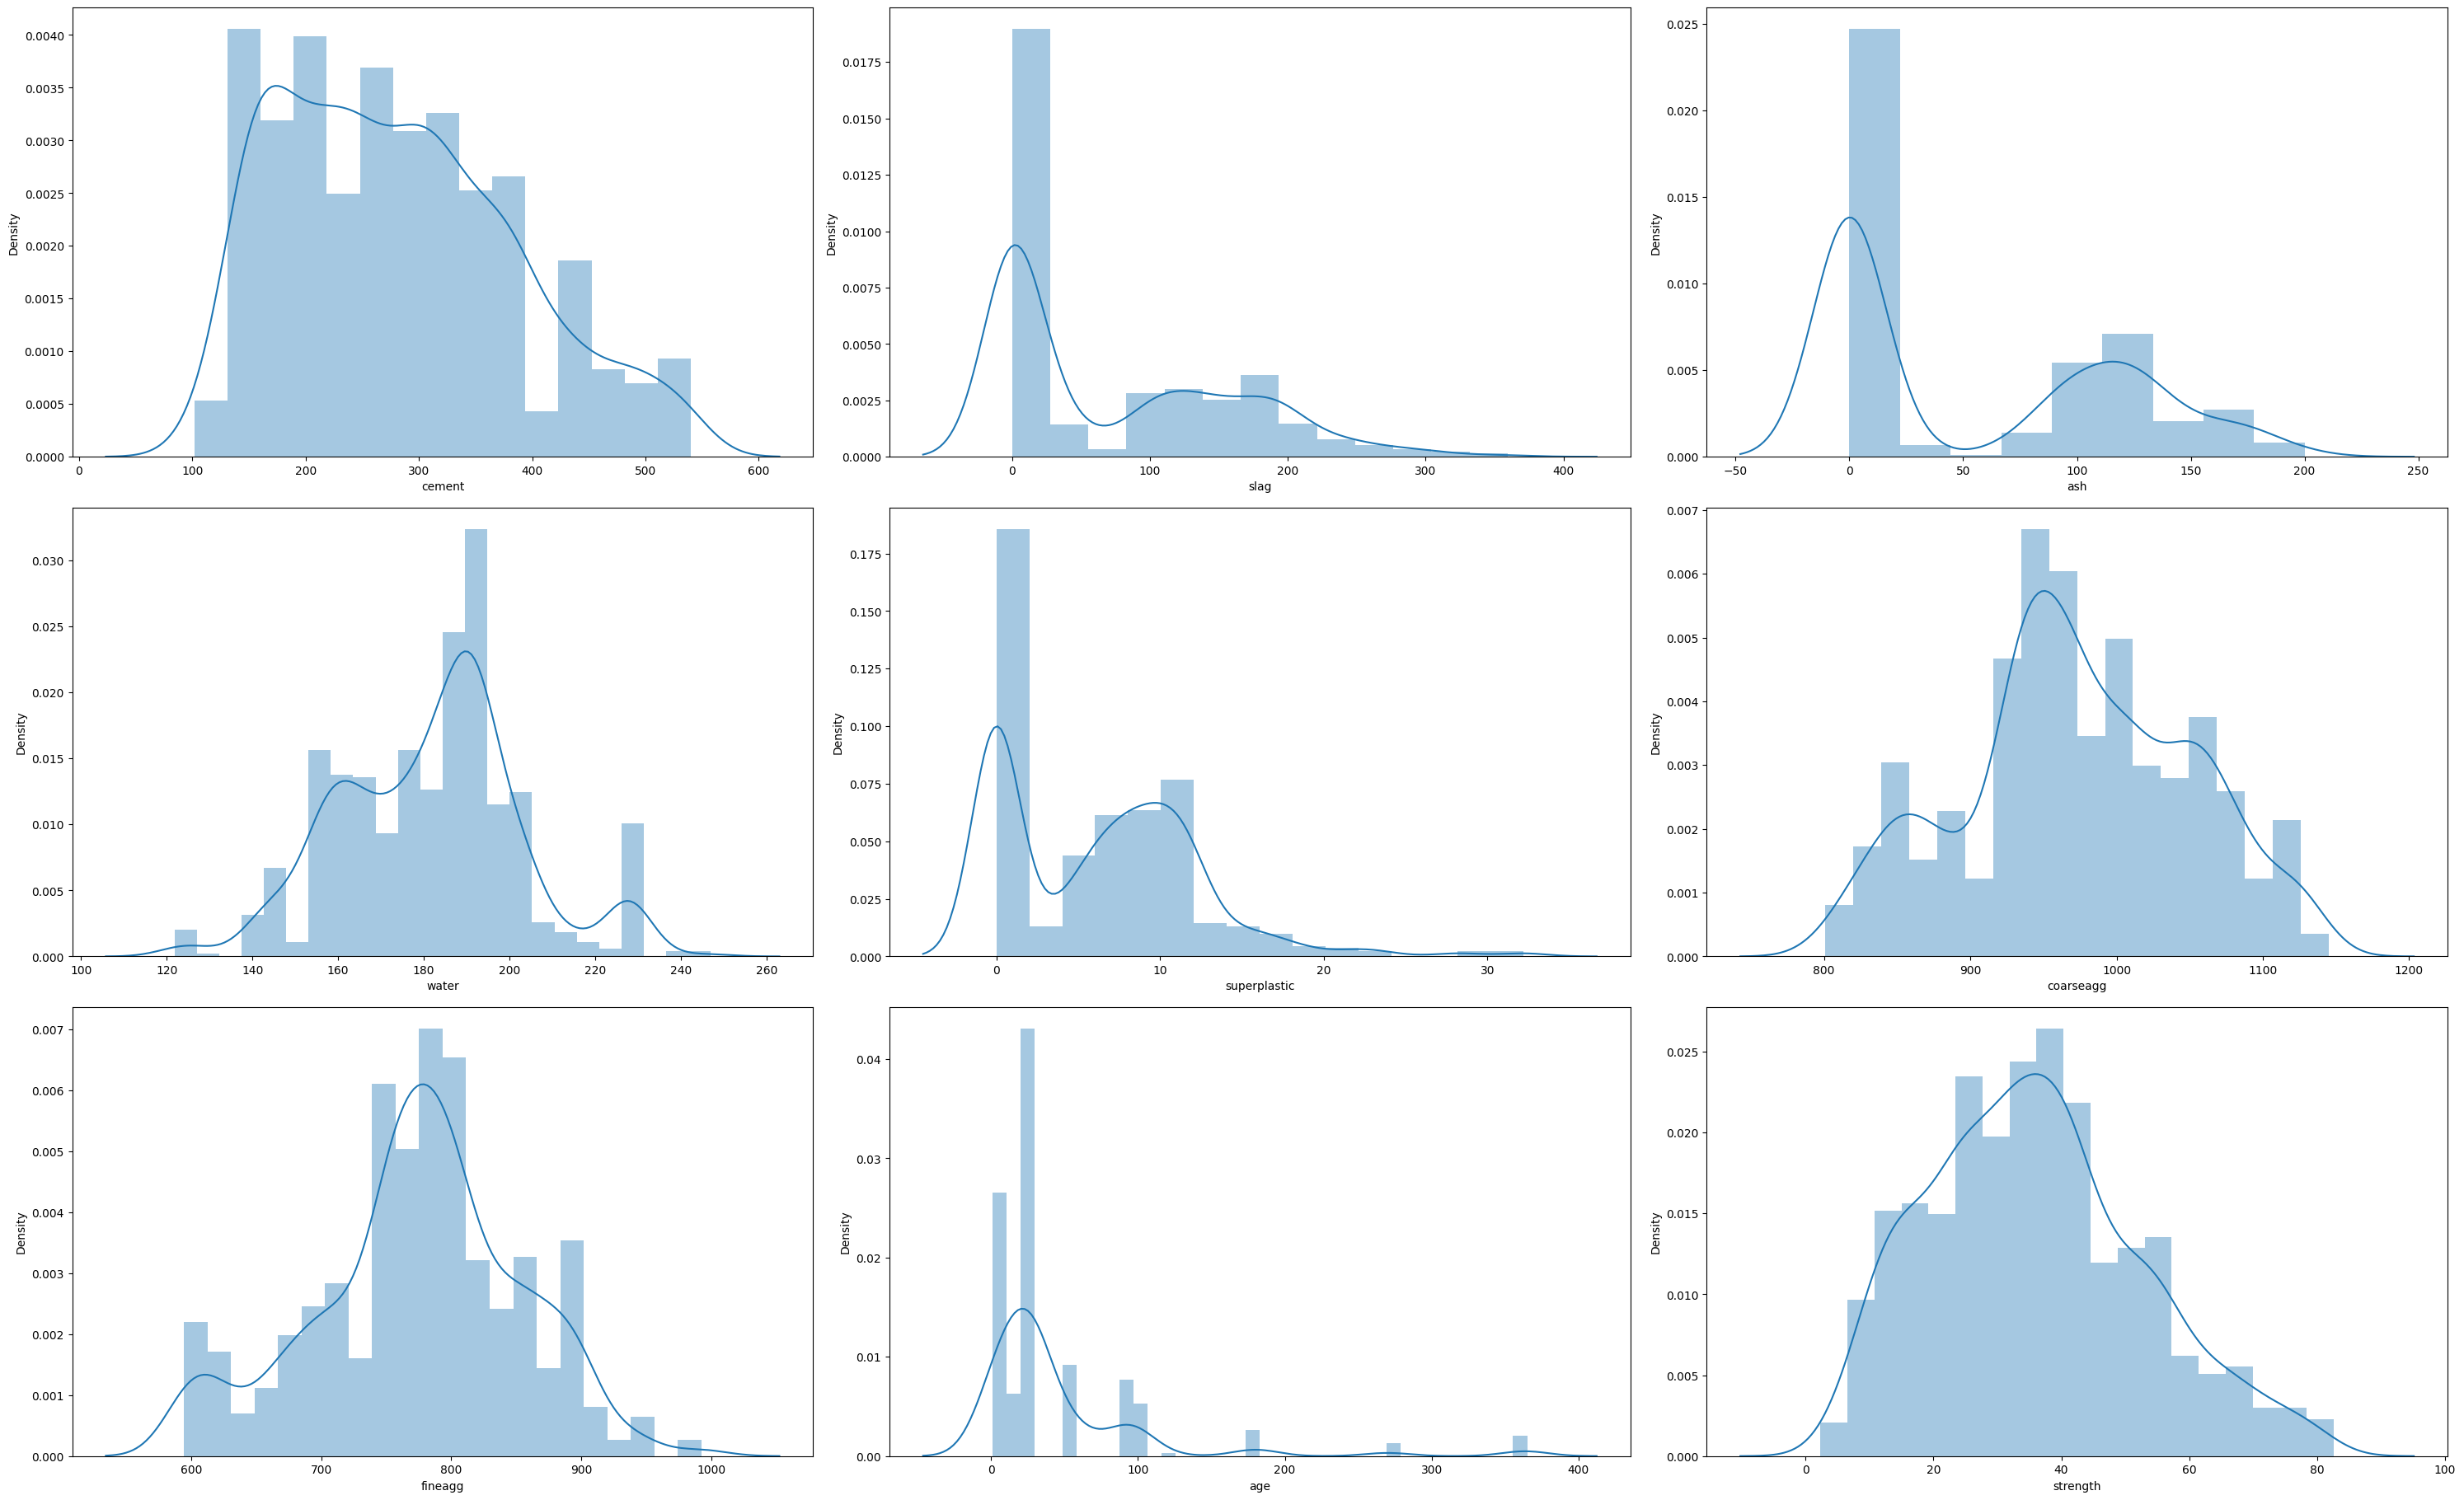

In [6]:
plt.figure(figsize=(30,30))
pltno = 1
for col in data:
  if pltno<=15:
    ax = plt.subplot(5,3,pltno)
    sns.distplot(x=data[col])
    plt.xlabel(col)
  pltno+=1
plt.tight_layout()

## Insights

1. **Cement** : The most of the datapoints lies between 150 to 350 and there is a huge drop at 400 and a slight rise after this till 550.

2. **Slag** : In this we can see the graph is skewed towards right as if the most datapoints lies in zero and we can see a sligh increase from 100 and gradually increases till 180 and decreases.

3. **ash** : In this also we can see the graph is skewed toeards righ as if the most datapoints lies in zero and we can see the remaining datapoints 80 and 200.

4. **Water** : In this the datapoints are laying between 140 to 230 and there are more number of data points at 180 to 200.

5. **superplastic** : The graph is skewed is towards right as if the most of the datapoints are in 0 and the remaing data points are between 5 to 20 .

6. **coarseagg** : In this the datapoints are laying between 800 to 1150 and the most number of datapoints are between 920 to 980.

7. **finaeagg** : In this the datapoints are laying between 600 to 1000 and most of the points are laying between 750 to 800.

8. **age** : In this the graph is skewed towards right as if the most of the datapoints are laying in 0 to 20 and the remaing datapoints are laying in 100,200,300.

## Bivariate Analysis

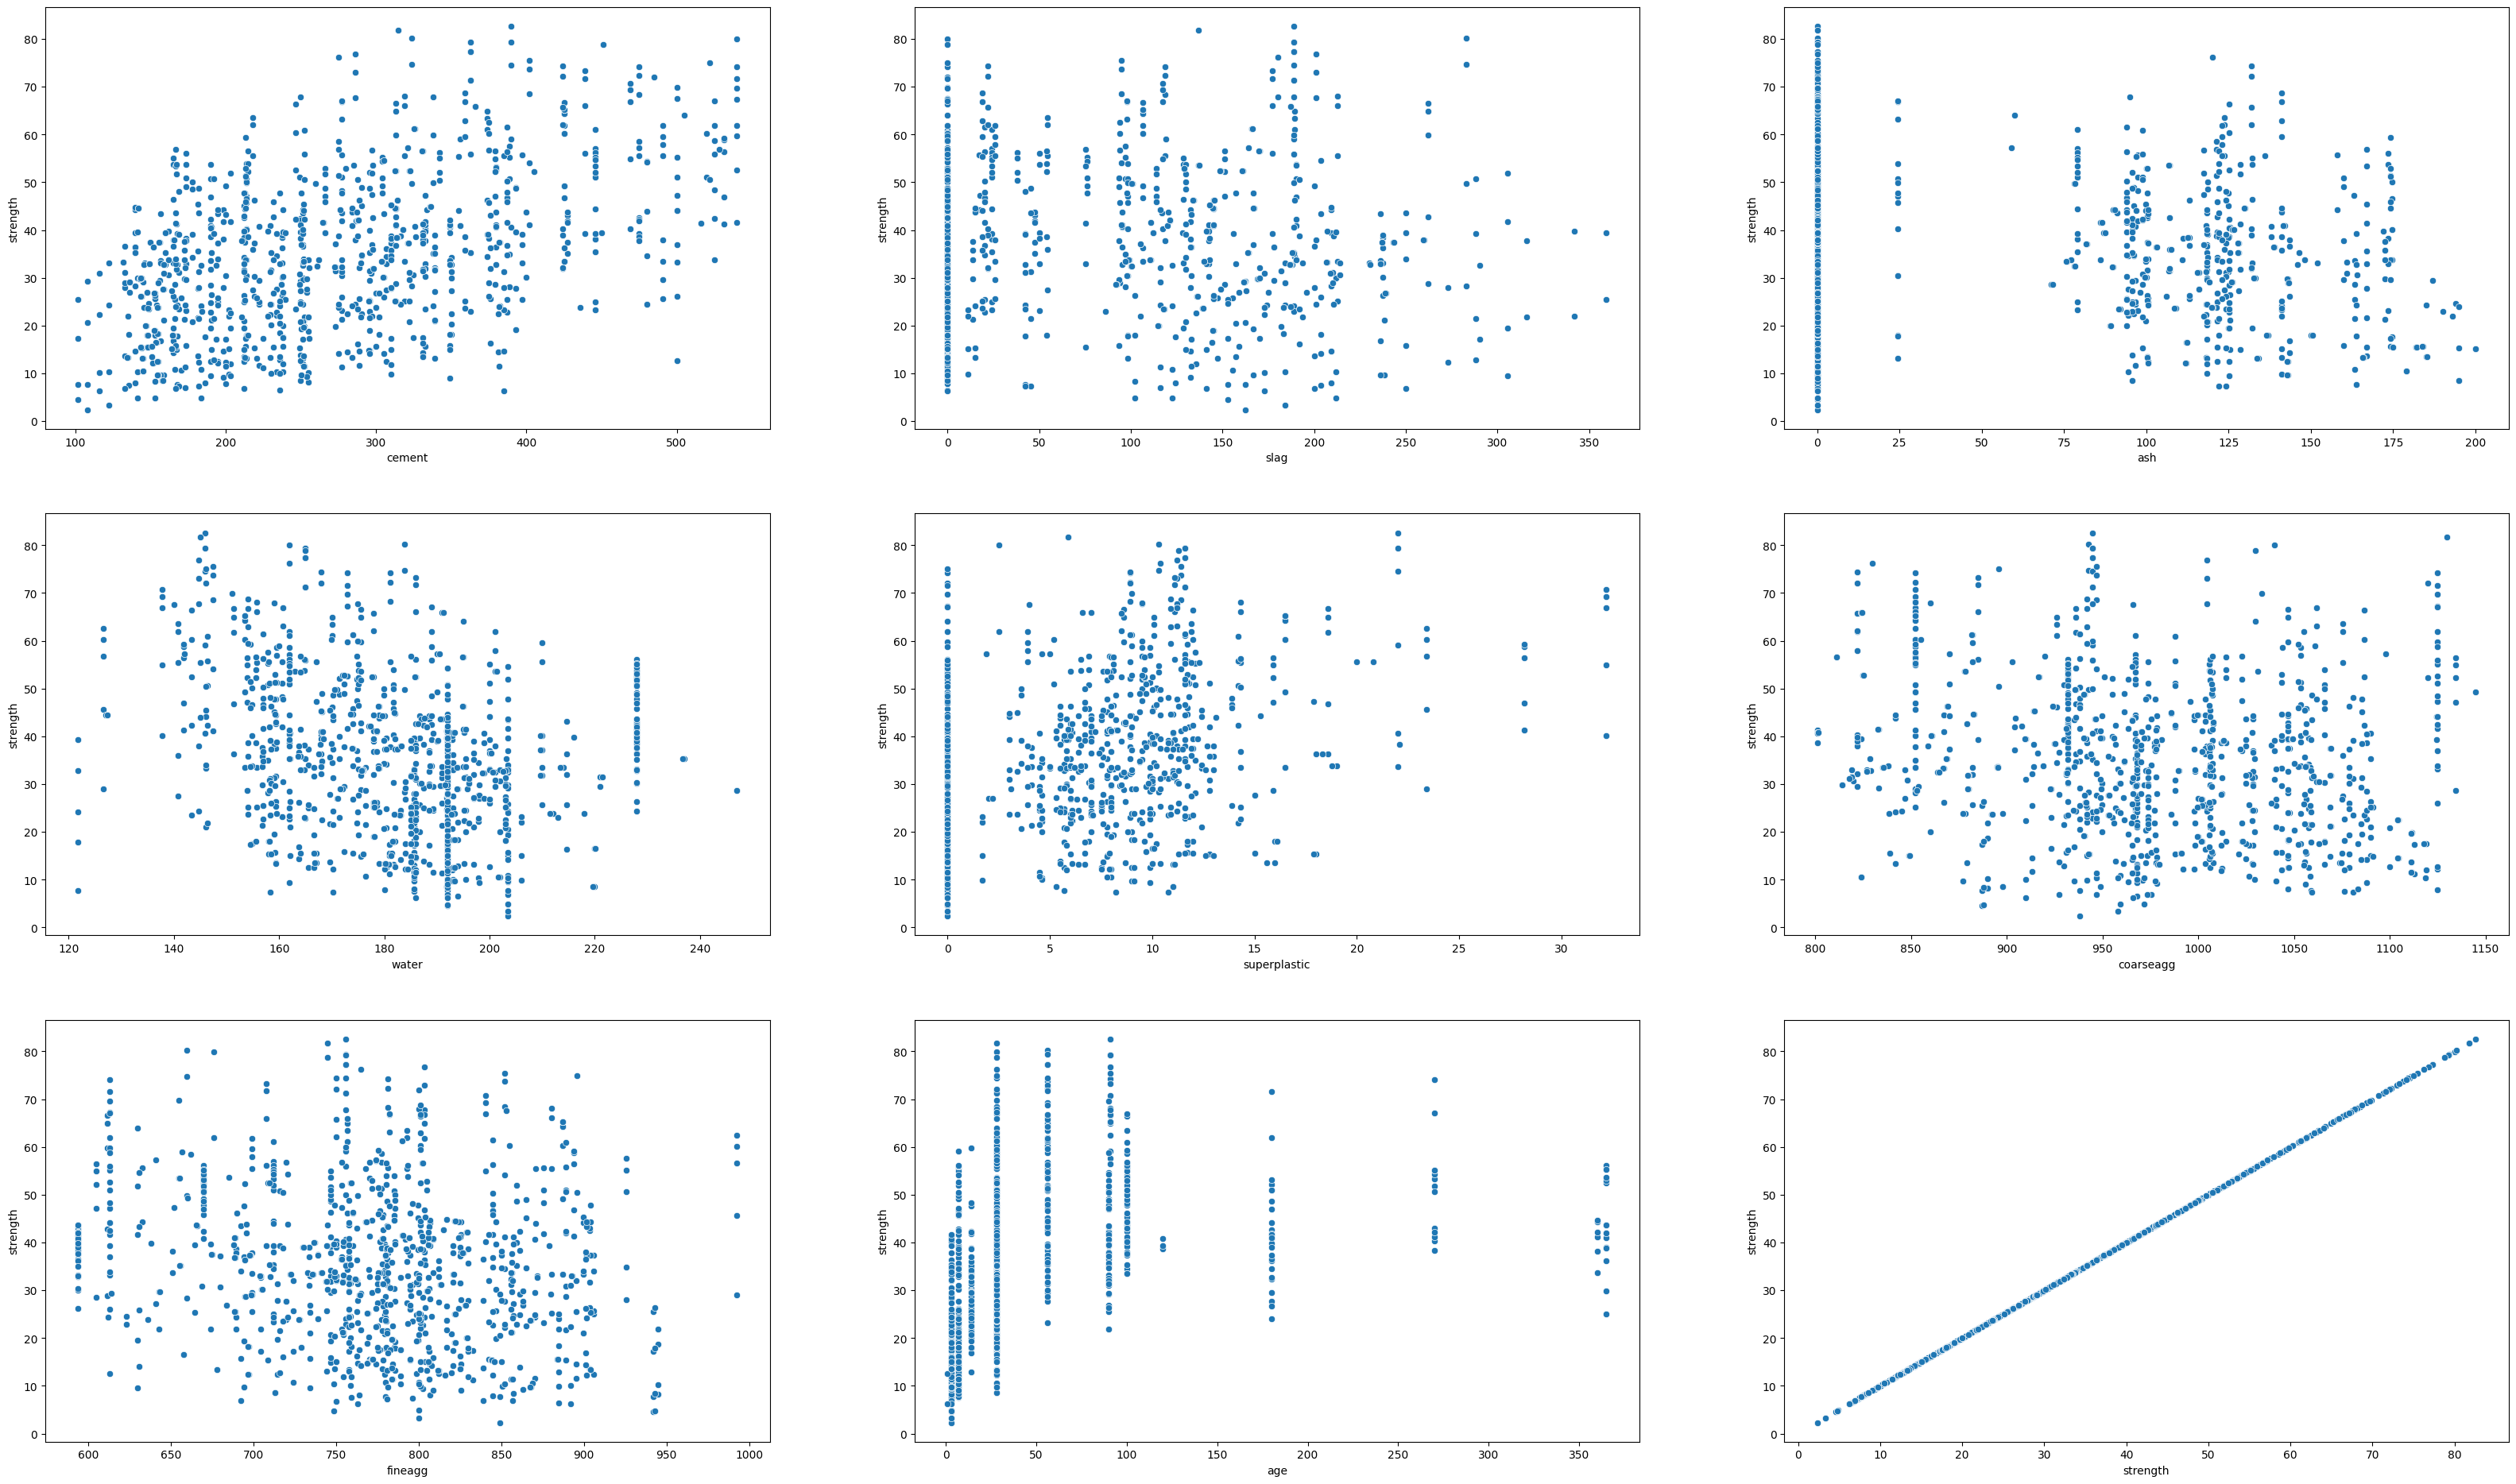

In [7]:
plt.figure(figsize=(40,40))
pltno = 1
for col in data:
  if pltno<=15:
    ax = plt.subplot(5,3,pltno)
    sns.scatterplot(x=data[col],y=data['strength'])
    plt.xlabel(col)
  pltno+=1
plt.show()

## Insights

1.  Optimal strength may be achieved with moderate cement levels around 300, but excessive cement doesn’t guarantee significantly higher strength.
2.  strength may be achieved when water level are between 140 to 180. but excessive water doesnot gurantee higher strength.
3.  the concrete can get strength when superplastic levels are between 5 to 12.
4. strength may be achieved when age of concrete is between 20 to 100.

## Multivariate Analysis

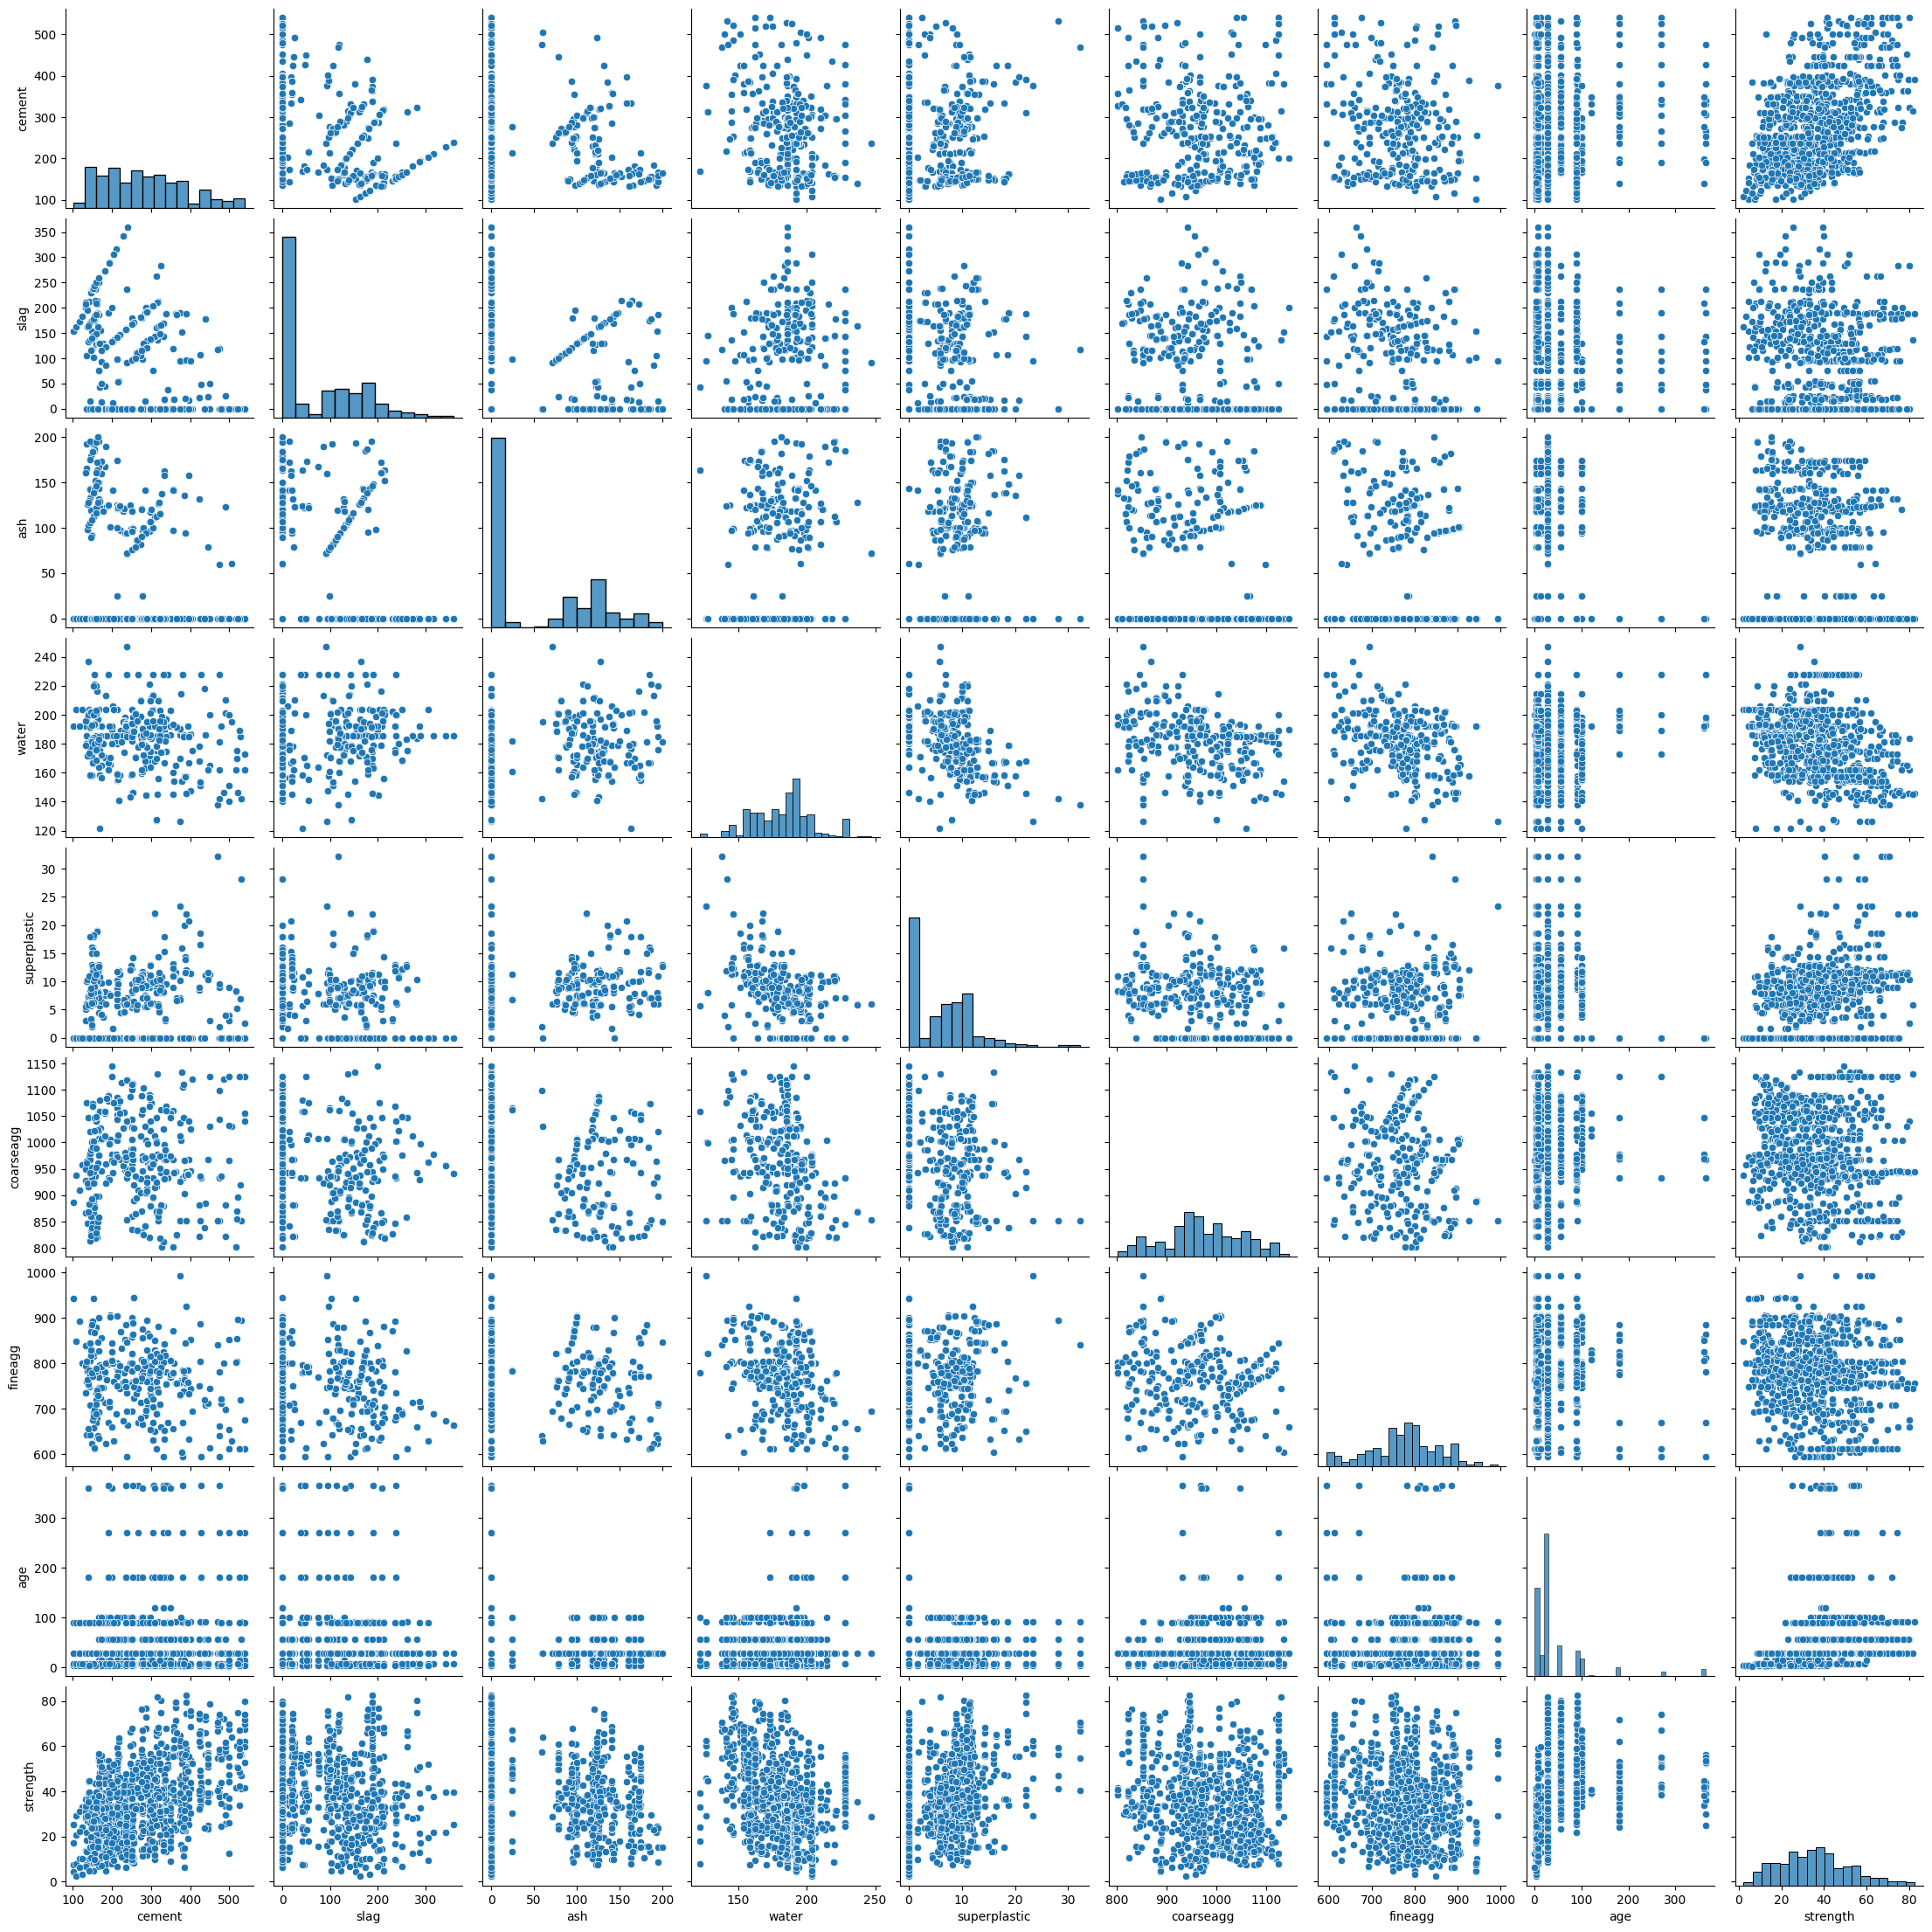

In [8]:
sns.pairplot(data)

## Data Preprocessing

In [9]:
data.isnull().sum() # checking for null values

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

#### There are no null values.

In [10]:
data.duplicated().sum() # checking if any duplictaes present.

25

In [11]:
data.drop_duplicates(inplace=True) # Dropping of duplicated datapoints.

### Outliers Handling

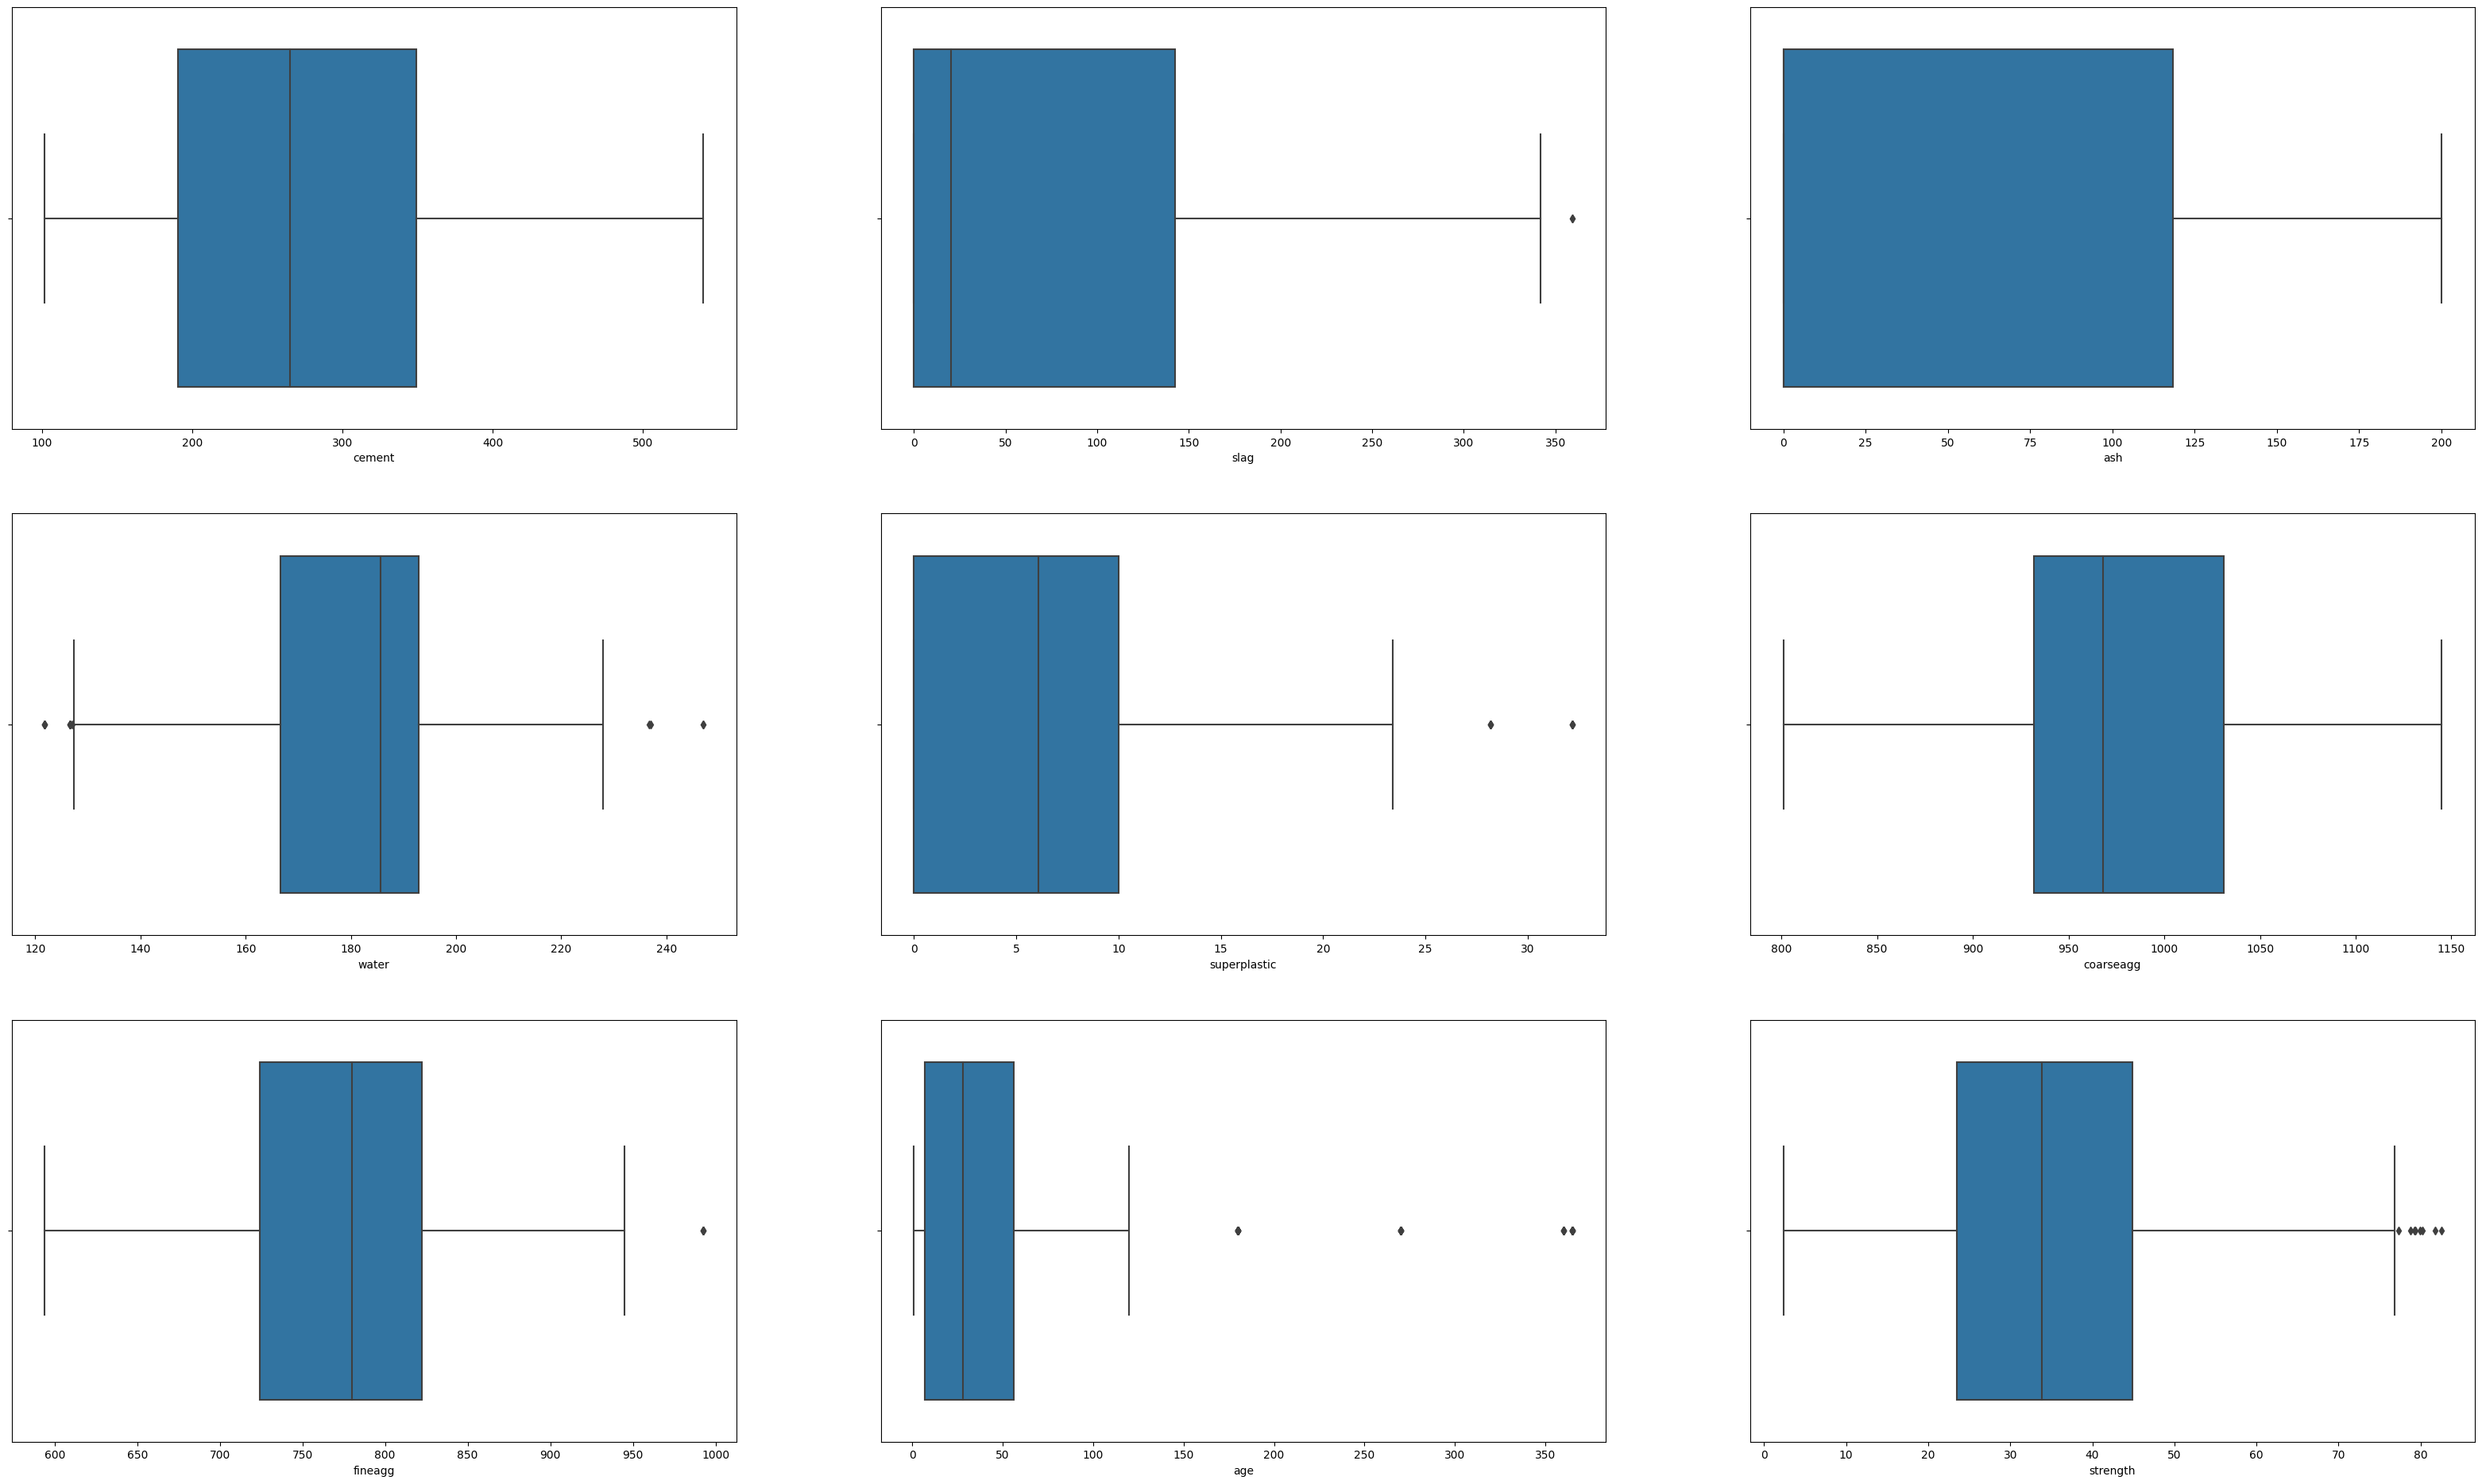

In [12]:
plt.figure(figsize=(40,40))
pltno = 1
for col in data:
  if pltno<=15:
    ax = plt.subplot(5,3,pltno)
    sns.boxplot(x=data[col])
    plt.xlabel(col)
  pltno+=1
plt.show()

##### From the above boxplot we get to see that there are minimal outliers which we can ignore.

### Scaling The Data

In [13]:
scale = MinMaxScaler()

df1 = scale.fit_transform(data)

In [14]:
data.columns

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

In [15]:
df = pd.DataFrame(df1,columns=['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'])

In [16]:
df.drop('strength',inplace=True,axis=1) # dropping of strength column as if it the target variable

# Feature Selection

<Axes: >

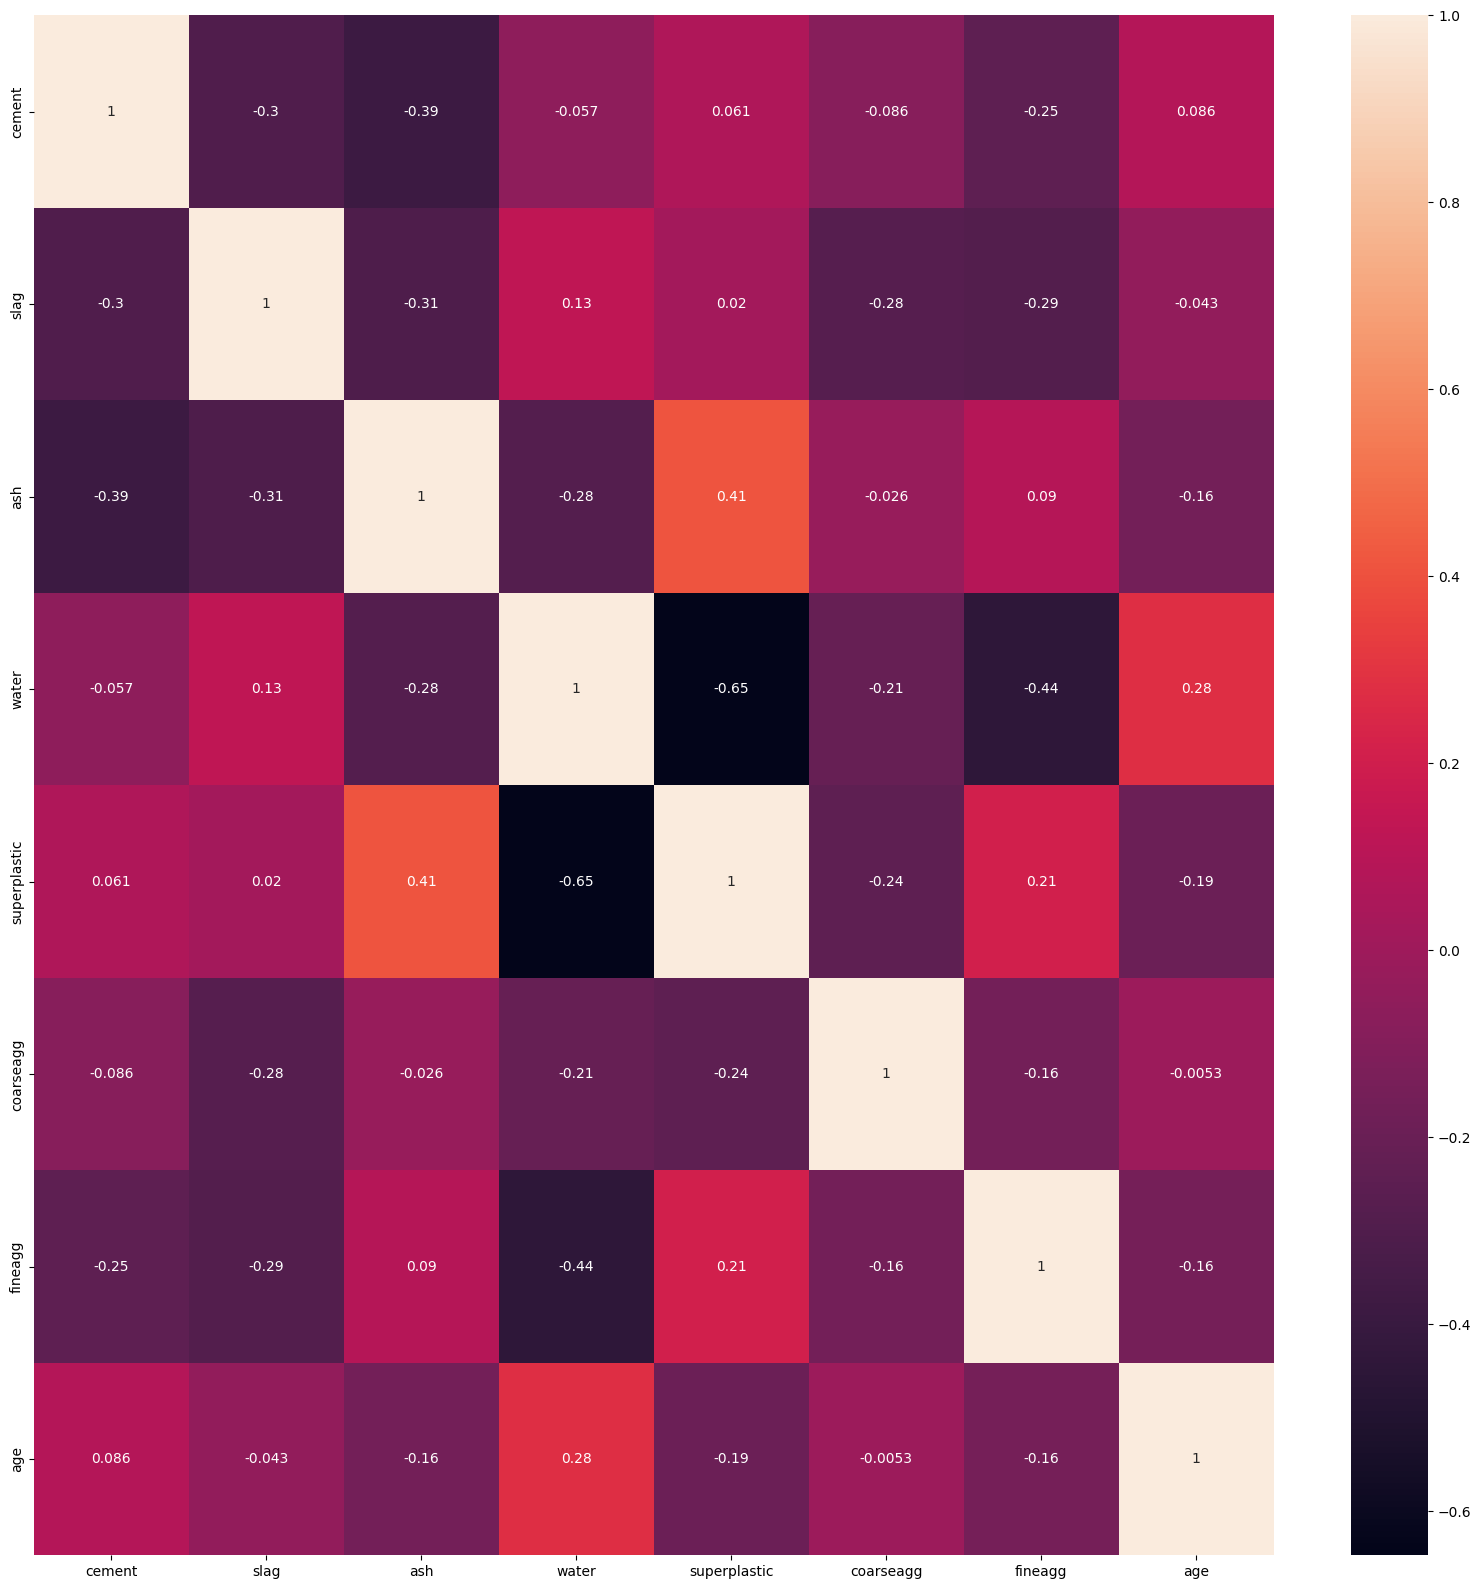

In [17]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(),annot=True)

# **TASK - 2**

## Model Creation

In [18]:
x = df
y = data['strength']

In [19]:
x_train , x_test , y_train , y_test = train_test_split(x,y,random_state=42)

In [20]:
def adjusted_r_squared(r_squared, n, p):
    """
    Calculate the adjusted R-squared score.

    Parameters:
        r_squared (float): The R-squared score.
        n (int): Number of samples.
        p (int): Number of predictors.

    Returns:
        float: The adjusted R-squared score.
    """
    adjusted_r2 = 1 - (1 - r_squared) * (n - 1) / (n - p - 1)
    return adjusted_r2

def run_multiple_algorithms(x_train, y_train, x_test, y_test, models):
    results = {}

    for model_name, model in models.items():
        # Train the model
        model.fit(x_train, y_train)

        # Make predictions
        y_pred = model.predict(x_test)

        # Calculate r2_score, mae & mse
        r2_score_value = r2_score(y_test, y_pred)
        mean_absolute_error_value = mean_absolute_error(y_test, y_pred)
        mean_squared_error_value = mean_squared_error(y_test, y_pred)
        
        # Calculate adjusted r2_score
        n = len(y_test)
        p = x_test.shape[1]
        adjusted_r2_score = adjusted_r_squared(r2_score_value, n, p)

        # Store results in the dictionary
        results[model_name] = {
            'r2_score': r2_score_value,
            'mae': mean_absolute_error_value,
            'mse': mean_squared_error_value,
            'rmse': np.sqrt(mean_squared_error_value),
            'adjusted_r2': adjusted_r2_score
        }

    return results

# Define the models to run
model_to_run = {
    'LinearRegression': LinearRegression(),
    'k-Neighbours Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'XGBRegressor': XGBRegressor()
}

# Run the models
results = run_multiple_algorithms(x_train, y_train, x_test, y_test, model_to_run)

# Print the results
for model, scores in results.items():
    print(f"Model: {model}")
    print(f"r2_score: {scores['r2_score']}")
    print(f"Adjusted r2_score: {scores['adjusted_r2']}")
    print(f"mean_absolute_error: {scores['mae']}")
    print(f"mean_squared_error: {scores['mse']}")
    print(f"Root Mean Squared Error (RMSE): {scores['rmse']}")
    print('=' * 30)

Model: LinearRegression
r2_score: 0.5644991091885495
Adjusted r2_score: 0.5501616313017528
mean_absolute_error: 8.936531775827403
mean_squared_error: 126.16199205625101
Root Mean Squared Error (RMSE): 11.2321855422821
Model: k-Neighbours Regressor
r2_score: 0.64706125557661
Adjusted r2_score: 0.6354418730441527
mean_absolute_error: 7.734444444444444
mean_squared_error: 102.24423419047619
Root Mean Squared Error (RMSE): 10.111589103126976
Model: Decision Tree
r2_score: 0.8436590508996902
Adjusted r2_score: 0.8385120237688157
mean_absolute_error: 4.354623015873015
mean_squared_error: 45.29103382936508
Root Mean Squared Error (RMSE): 6.729861352908029
Model: RandomForestRegressor
r2_score: 0.8969082884858708
Adjusted r2_score: 0.893514322674706
mean_absolute_error: 3.715093061224491
mean_squared_error: 29.86504956368031
Root Mean Squared Error (RMSE): 5.46489245673511
Model: XGBRegressor
r2_score: 0.9249391371316262
Adjusted r2_score: 0.9224679976133259
mean_absolute_error: 2.970005070709

## Model Comaparison Report                            (without hyperparameters)

In [21]:
pd.DataFrame(results).T #creating of dataframe for the given results

,r2_score,mae,mse,rmse,adjusted_r2
LinearRegression,0.564499,8.936532,126.161992,11.232186,0.550162
k-Neighbours Regressor,0.647061,7.734444,102.244234,10.111589,0.635442
Decision Tree,0.843659,4.354623,45.291034,6.729861,0.838512
RandomForestRegressor,0.896908,3.715093,29.865050,5.464892,0.893514
XGBRegressor,0.924939,2.970005,21.744681,4.663119,0.922468


In [22]:
def adjusted_r2_score(r2, n, p):
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

def run_multiple_algorithms_with_hyperparams(x_train, y_train, x_test, y_test, models_with_params):
    results = {}

    for model_name, (model, params) in models_with_params.items():
        # Perform GridSearchCV to find the best hyperparameters
        grid_search = GridSearchCV(estimator=model, param_grid=params, cv=5, scoring='neg_mean_squared_error')
        grid_search.fit(x_train, y_train)

        # Get the best model from grid search
        best_model = grid_search.best_estimator_

        # Train the best model
        best_model.fit(x_train, y_train)

        # Make predictions
        y_pred = best_model.predict(x_test)

        # Calculate r2_score, mae & mse
        r2_score_value = r2_score(y_test, y_pred)
        mean_absolute_error_value = mean_absolute_error(y_test, y_pred)
        mean_squared_error_value = mean_squared_error(y_test, y_pred)
        adjusted_r2 = adjusted_r2_score(r2_score_value, len(y_test), x_test.shape[1])

        # Store results in the dictionary
        results[model_name] = {
            'best_params': grid_search.best_params_,
            'r2_score': r2_score_value,
            'adjusted_r2': adjusted_r2,
            'mae': mean_absolute_error_value,
            'mse': mean_squared_error_value,
            'rmse': np.sqrt(mean_squared_error_value)
        }

    return results

# Define models with hyperparameters
models_with_params = {
    'LinearRegression': (LinearRegression(), {}),
    'k-Neighbours Regressor': (KNeighborsRegressor(), {'n_neighbors': [3, 5, 7]}),
    'Decision Tree': (DecisionTreeRegressor(), {'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}),
    'RandomForestRegressor': (RandomForestRegressor(), {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}),
    'XGBRegressor': (XGBRegressor(), {'learning_rate': [0.01, 0.1, 0.3], 'max_depth': [3, 5, 7], 'min_child_weight': [1, 3, 5], 'gamma': [0, 0.1, 0.2], 'subsample': [0.5, 0.7, 0.9], 'colsample_bytree': [0.5, 0.7, 0.9]})
}

# Run models with hyperparameters
results_hyperparams = run_multiple_algorithms_with_hyperparams(x_train, y_train, x_test, y_test, models_with_params)

# Print the results
for model, scores in results_hyperparams.items():
    print(f"Model: {model}")
    print(f"Best Parameters: {scores['best_params']}")
    print(f"r2_score: {scores['r2_score']}")
    print(f"Adjusted R-squared: {scores['adjusted_r2']}")
    print(f"mean_absolute_error: {scores['mae']}")
    print(f"mean_squared_error: {scores['mse']}")
    print(f"Root Mean Squared Error (RMSE): {scores['rmse']}")
    print('=' * 30)


Model: LinearRegression
Best Parameters: {}
r2_score: 0.5644991091885495
Adjusted R-squared: 0.5501616313017528
mean_absolute_error: 8.936531775827403
mean_squared_error: 126.16199205625101
Root Mean Squared Error (RMSE): 11.2321855422821
Model: k-Neighbours Regressor
Best Parameters: {'n_neighbors': 5}
r2_score: 0.64706125557661
Adjusted R-squared: 0.6354418730441527
mean_absolute_error: 7.734444444444444
mean_squared_error: 102.24423419047619
Root Mean Squared Error (RMSE): 10.111589103126976
Model: Decision Tree
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
r2_score: 0.8535802221371398
Adjusted R-squared: 0.848759817927663
mean_absolute_error: 4.500916005291006
mean_squared_error: 42.41693011739418
Root Mean Squared Error (RMSE): 6.512828119749068
Model: RandomForestRegressor
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
r2_score: 0.8977686735311157
Adjusted R-squared: 0.8944030331535392

## Model Creation Report  (with hyperparameters)

In [23]:
pd.DataFrame(results_hyperparams).T

,best_params,r2_score,adjusted_r2,mae,mse,rmse
LinearRegression,{},0.564499,0.550162,8.936532,126.161992,11.232186
k-Neighbours Regressor,{'n_neighbors': 5},0.647061,0.635442,7.734444,102.244234,10.111589
Decision Tree,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.85358,0.84876,4.500916,42.41693,6.512828
RandomForestRegressor,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.897769,0.894403,3.719465,29.615801,5.44204
XGBRegressor,"{'colsample_bytree': 0.9, 'gamma': 0.2, 'learn...",0.94255,0.940659,2.727253,16.642907,4.079572


### As you can see from the above results XGBRegressor performs better compared to the other algorithms.

# Report on Challenges Faced

#### In this we didnot face much challenges as there were very less observations and there were no null values,no outliers and very less number of duplicates.